# Initialize the notebook

In [1]:
import sys
import importlib
import numpy as np

godfather_dir = '/Users/sloenen/Documents/00_Github_code/00_Delft_Networks/00_Magnetic_Field_calculations'
if godfather_dir not in sys.path:
    sys.path.append(godfather_dir) 

f = importlib.import_module('01_scripts.Cluster_Funcs'); importlib.reload(f)

<module '01_scripts.Cluster_Funcs' from '/Users/sloenen/Documents/00_Github_code/00_Delft_Networks/00_Magnetic_Field_calculations/01_scripts/Cluster_Funcs.py'>

# Calculate $B_z$ and $B_x$ fields for stripline configuration

References <br>
1 https://iopscience.iop.org/article/10.1088/0022-3727/39/9/003/pdf <br>
2 https://www.nature.com/articles/srep08745.pdf

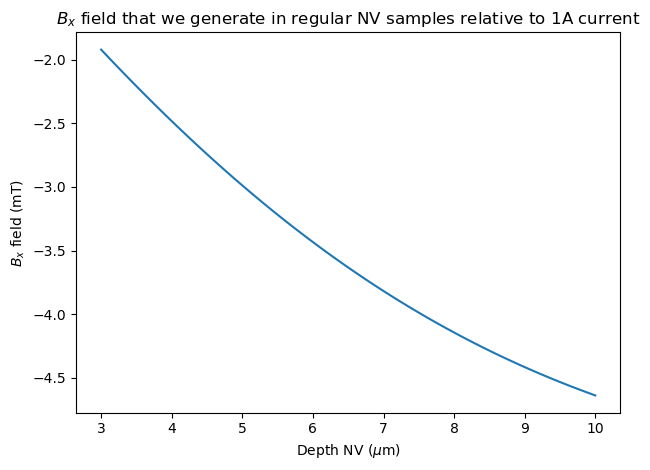

In [2]:
w_stripline_NV = 20e-6 # Width NV stripline
d_SIL_NV = 20e-6 # diameter SIL NV is in 
depth_NV = np.linspace(3e-6,10e-6,100) # Depth under the surface the NV is located. The stripline is on the surface.

f.Bx_field_depth_NV_current_1A(depth_NV, d_SIL_NV, w_stripline_NV)

In [3]:
# Nanopillar parameters
NP_dict = {}
NP_dict['Spacing_NP'] = 1e-6 # x-Spacing between the edges of the nanopillars
NP_dict['Width_NP'] = 300e-9 # Width of a single nanopillar
# NP_dict['Cntrs'] = np.array([1.68, 2.3,3.3,4.3,4.92])*1e-6
if 'Cntrs' in NP_dict:
    NP_dict['N_NP'] = len(NP_dict['Cntrs']) # Number of nanopillars
else:
    NP_dict['N_NP'] = 4 # Number of nanopillars

# Micromagnet parameters
MM_dict = {}
MM_dict['Spacing_MM_NP'] = 200e-9 # Spacing between the edges of the micromagnet and the nanopillar 
MM_dict['M_es'] = 4.9e5 # Page 2 second reference
MM_dict['w_MM'] = 2e-6  # Width of a single micromagnet
MM_dict['h_MM'] = 100e-9 # Height of a single micromagnet
MM_dict['Nr_MM'] = 2 # Nuber of micromagnets: Only 1 and 2 are currently allowed
MM_dict['x_Cntrs'] = [0, 3e-6] # x-positions of the center of the micromagnets
MM_dict['zMM_is_zNP'] = True # z-position of bottom of micromagnet is level with the top of the nanopillars 

# Stripline parameters
SL_dict = {}
SL_dict['Spacing_SL_MM'] = 200e-9 # Spacing between the edges of a micromagnet and a stripline
SL_dict['w_SL'] = 20e-6 # Width of a single stripline
SL_dict['Nr_SL'] = 1 # Number of striplines: Only 1 and 2 are currently allowed
SL_dict['Spacing_SL'] = 80e-6 # Spacing between the edges of two striplines

NP_dict, MM_dict, SL_dict = f.centers_calculation(NP_dict, MM_dict, SL_dict)
location_dict, freq_dict, B_dict = f.calculate_magnetic_fields_and_gradients(NP_dict, MM_dict, SL_dict)

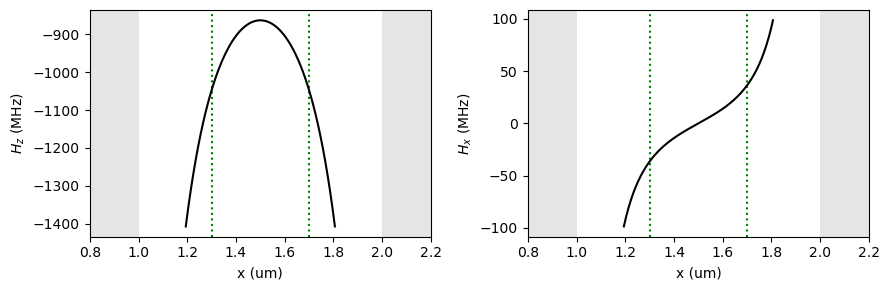

In [4]:
zslice_array = np.array([0.6e-6])
fx_max = 100e6
y_scale_log = False
save_fig_freq = False
save_data_to_publish = False
max_fx = 10

fx_max_x_Idxs = f.graphical_frequency_representation(zslice_array, NP_dict, MM_dict, SL_dict, location_dict, \
                                                     freq_dict, fx_max = fx_max, y_scale_log = y_scale_log, \
                                                     save_fig = save_fig_freq, save_data_to_publish = save_data_to_publish)

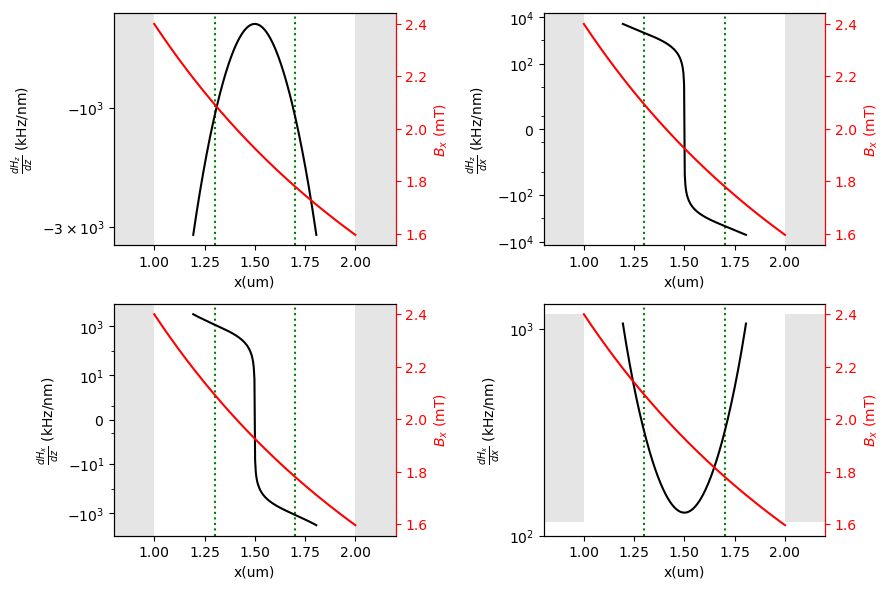

In [5]:
y_scale_log = True
save_fig_freqGrad = False
save_data_to_publish = False
plot_B_field = True

f.graphical_delta_frequency_Bfield_representation(zslice_array, NP_dict, MM_dict, SL_dict,\
                                                  location_dict, freq_dict, fx_max, B_dict, \
                                                  plot_B_field = plot_B_field, y_scale_log = y_scale_log, \
                                                  save_fig = save_fig_freqGrad, save_data_to_publish = save_data_to_publish)